# 🍄 Mushroom Classification with VGG19 & PyTorch

This notebook trains a mushroom image classifier using transfer learning with **VGG19** pretrained on ImageNet.

**Pipeline overview:**
1. Load image paths + labels from a CSV on S3
2. Stream images directly from S3 (no full download needed)
3. Fine-tune VGG19 with a custom classification head
4. Track metrics, plot curves, and save the best model back to S3

---
### Expected S3 structure
```
s3://your-bucket/
├── images/
│   ├── amanita_001.jpg
│   ├── chanterelle_042.jpg
│   └── ...
└── labels.csv          # columns: filename, label
```

The CSV must have at least two columns:
- `filename` — image file name (e.g. `amanita_001.jpg`)
- `label`    — class name (e.g. `amanita`)

## 1 · Install dependencies

In [1]:
!pip install torch torchvision boto3 pandas scikit-learn matplotlib seaborn tqdm Pillow --quiet

## 2 · Configuration — **edit this cell**

In [ ]:
#Was done on kaggle notebook to have free gpu
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()

import os
os.environ["AWS_ACCESS_KEY_ID"]     = secrets.get_secret("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = secrets.get_secret("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_DEFAULT_REGION"]    = "eu-north-1"   # adjust to your region

print("Credentials loaded !")

Credentials loaded ✅


In [ ]:
import boto3
sts = boto3.client("sts")
print(sts.get_caller_identity())

In [4]:
!pip install awscli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 41.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 90.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 33.5 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
  Attempting uninstall: botocore
    Found existing installation: botocore 1.42.70
    Uninstalling botocore-1.42.70:
      Successfully uninstalled botocore-1.42.70
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
goo

In [5]:
!aws s3 ls s3://fungiapp/Data/

2026-04-08 11:41:12 5157830981 images.zip
2026-04-02 19:49:40    9636354 mushroom2.csv


In [6]:
!aws s3 cp s3://fungiapp/Data/images.zip .

download: s3://fungiapp/Data/images.zip to ./images.zip            


In [7]:
!unzip images.zip

Archive:  images.zip
   creating: images/
  inflating: images/img_0.jpg        
  inflating: images/img_1.jpg        
  inflating: images/img_10.jpg       
  inflating: images/img_100.jpg      
  inflating: images/img_1000.jpg     
  inflating: images/img_10000.jpg    
  inflating: images/img_10001.jpg    
  inflating: images/img_10002.jpg    
  inflating: images/img_10003.jpg    
  inflating: images/img_10004.jpg    
  inflating: images/img_10005.jpg    
  inflating: images/img_10006.jpg    
  inflating: images/img_10007.jpg    
  inflating: images/img_10008.jpg    
  inflating: images/img_10009.jpg    
  inflating: images/img_1001.jpg     
  inflating: images/img_10010.jpg    
  inflating: images/img_10011.jpg    
  inflating: images/img_10012.jpg    
  inflating: images/img_10013.jpg    
  inflating: images/img_10014.jpg    
  inflating: images/img_10015.jpg    
  inflating: images/img_10016.jpg    
  inflating: images/img_10017.jpg    
  inflating: images/img_10018.jpg    
  inflat

In [8]:
# S3
S3_BUCKET      = "fungiapp"          
S3_IMAGES_DIR  = "Data/images/"                    
S3_CSV_KEY     = "Data/mushroom2.csv"               
AWS_REGION     = "eu-north-1"             


# Local images (use after unzip on Kaggle)
USE_LOCAL_IMAGES  = True          # False: load images from S3
LOCAL_IMAGES_ROOT = "./images"  

# Column in CSV
CSV_FILENAME_COL  = "image_filename"
CSV_LABEL_COL     = "scientific_name"  # target
CSV_EDIBILITY_COL = "edibility"        # safety signal

# Non-edible priority settings
NON_EDIBLE_VALUES      = {"poisonous", "inedible", "unknown"}
EDIBILITY_RECALL_BOOST = 1.75  # >1.0 increases penalty for missing non-edible samples

# Training
BATCH_SIZE     = 32
NUM_EPOCHS     = 20
LEARNING_RATE  = 1e-4
VAL_SPLIT      = 0.15
TEST_SPLIT     = 0.10
RANDOM_SEED    = 42
NUM_WORKERS    = 0  

# Fine-tuning strategy
# 'head_only'  → freeze all VGG19 features, train new classifier head only
# 'full'       → unfreeze everything after head_only warm-up
# 'last_block' → unfreeze only the last conv block + classifier
FINETUNE_STRATEGY = "last_block"
WARMUP_EPOCHS     = 3      # epochs with frozen backbone before full unfreeze

# Output
MODEL_SAVE_PATH   = "best_vgg19_mushroom.pth"   # local path
S3_MODEL_KEY      = "models/best_vgg19_mushroom.pth"  # upload destination

print("Configuration loaded !")

Configuration loaded !


## 3 · Imports

In [9]:
import io, os, random, time
from pathlib import Path
from collections import defaultdict

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

# Reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
  GPU: Tesla T4


## 4 · Load CSV from S3

In [10]:
s3 = boto3.client("s3", region_name=AWS_REGION)

# Read CSV
print(f"Reading s3://{S3_BUCKET}/{S3_CSV_KEY} …")
obj = s3.get_object(Bucket=S3_BUCKET, Key=S3_CSV_KEY)
df  = pd.read_csv(obj["Body"])

print(f"Total samples : {len(df):,}")
print(f"Columns       : {list(df.columns)}")
df.head()

Reading s3://fungiapp/Data/mushroom2.csv …
Total samples : 36,147
Columns       : ['Unnamed: 0', 'id', 'latitude', 'longitude', 'observed_on', 'place_guess', 'place_country_name', 'species_guess', 'scientific_name', 'common_name', 'image_filename', 'description', 'edibility', 'new_description']


,Unnamed: 0,id,latitude,longitude,observed_on,place_guess,place_country_name,species_guess,scientific_name,common_name,image_filename,description,edibility,new_description
0,0,541,37.848400,-122.194000,2008-08-13,"Sibley Volcanic Regional Park, Oakland, CA",United States,The Prince,Agaricus augustus,Agaric impérial,img_0.jpg,Growing under Monterey Pine on a ridge. What ...,edible,Large edible mushroom with strong almond-like ...
1,1,8096,37.878338,-122.230186,2010-08-20,"Berkeley, CA, USA",United States,The Prince,Agaricus augustus,Agaric impérial,img_1.jpg,"I believe this is <i>Agaricus augustus</i>, ak...",edible,Large edible mushroom with strong almond-like ...
2,2,8346,51.638424,-0.622358,2010-09-18,"Beaconsfield, Buckinghamshire, England",United Kingdom,Horse Mushroom,Agaricus arvensis,Agaric des jachères,img_2.jpg,NaN,edible,"Edible 'horse mushroom,' grows in fields and m..."
3,3,22169,-28.225019,153.126240,2009-09-06,"Lamington National Park, Queensland, Australia",Australia,Ear fungus,Auricularia cornea,Champignon noir,img_3.jpg,"Lamington National Park, Queensland, Australia",edible,"Edible jelly fungus, dark brown, often called ..."
4,4,40581,37.788624,-122.247405,2011-11-28,"Vantage Point Park, Oakland, CA, US",United States,Yellow Stainer,Agaricus xanthodermus,Agaric jaunissant,img_4.jpg,City Slicker Mushrooms growing in Vantage Poin...,poisonous,"Poisonous yellow-staining mushroom, often mist..."



Number of classes : 27
Classes           : ['Agaricus', 'Agaricus arvensis', 'Agaricus augustus', 'Agaricus bernardii', 'Agaricus bisporus', 'Agaricus bitorquis', 'Agaricus bohusii', 'Agaricus bresadolanus', 'Agaricus campestris', 'Agaricus crocodilinus', 'Agaricus moelleri', 'Agaricus sylvaticus', 'Agaricus sylvicola', 'Agaricus xanthodermus', 'Auricularia cornea', 'Auricularia nigricans', 'Ctenactis albitentaculata', 'Ctenactis crassa', 'Ctenactis echinata', 'Cynomorium coccineum', 'Fungia fungites', 'Lobactis scutaria', 'Marasmius oreades', 'Melochia tomentosa', 'Polyphyllia talpina', 'Sarcophyton', 'Tetratoma fungorum']

Edibility distribution:
edibility
edible       24481
poisonous     6046
inedible      4844
unknown        776
Name: count, dtype: int64

Species marked non-edible: 14/27


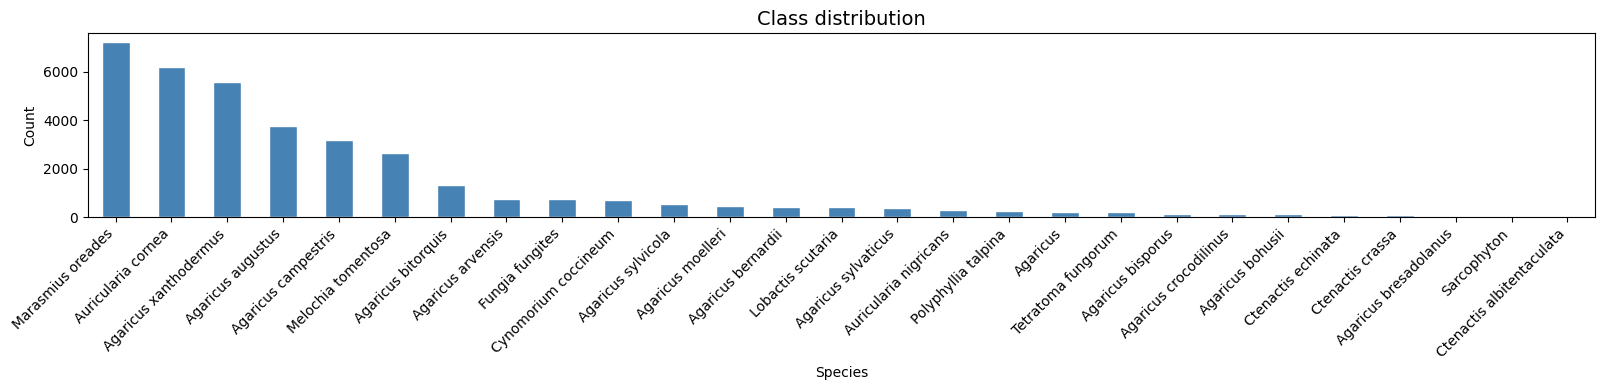

In [11]:
# Validate required columns
assert CSV_FILENAME_COL in df.columns, f"Column '{CSV_FILENAME_COL}' not found in CSV"
assert CSV_LABEL_COL    in df.columns, f"Column '{CSV_LABEL_COL}' not found in CSV"
assert CSV_EDIBILITY_COL in df.columns, f"Column '{CSV_EDIBILITY_COL}' not found in CSV"

df = df[[CSV_FILENAME_COL, CSV_LABEL_COL, CSV_EDIBILITY_COL]].dropna()
df.columns = ["image_filename", "scientific_name", "edibility"]

df["edibility"] = df["edibility"].astype(str).str.strip().str.lower()
df["is_non_edible"] = df["edibility"].isin(NON_EDIBLE_VALUES).astype(np.int64)

# Encode labels
classes     = sorted(df["scientific_name"].unique())
label2idx   = {c: i for i, c in enumerate(classes)}
idx2label   = {i: c for c, i in label2idx.items()}
NUM_CLASSES = len(classes)

df["label_idx"] = df["scientific_name"].map(label2idx)

species_non_edible_rate = df.groupby("scientific_name")["is_non_edible"].mean()
class_is_non_edible = np.array([
    int(species_non_edible_rate.get(c, 0.0) >= 0.5) for c in classes
], dtype=np.int64)

print(f"\nNumber of classes : {NUM_CLASSES}")
print("Classes           :", classes)
print("\nEdibility distribution:")
print(df["edibility"].value_counts(dropna=False))
print(f"\nSpecies marked non-edible: {int(class_is_non_edible.sum())}/{NUM_CLASSES}")

# Class distribution
fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES * 0.6), 4))
df["scientific_name"].value_counts().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Class distribution", fontsize=14)
ax.set_xlabel("Species")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5 · Train / Val / Test split

In [12]:
train_df, temp_df = train_test_split(
    df, test_size=VAL_SPLIT + TEST_SPLIT,
    stratify=df["label_idx"], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    stratify=temp_df["label_idx"], random_state=RANDOM_SEED
)

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name:5s}: {len(split):,} samples")

Train: 27,110 samples
Val  : 5,422 samples
Test : 3,615 samples


## 6 · Dataset — streams images

In [13]:
class MushroomLocalDataset(Dataset):
    """Load images from disk (e.g. folder created by unzip on Kaggle)."""

    def __init__(self, dataframe: pd.DataFrame, images_root: str, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.root = Path(images_root).expanduser().resolve()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel = Path(str(row["image_filename"]).strip())
        path = self.root / rel
        label = int(row["label_idx"])
        is_non_edible = int(row["is_non_edible"])

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)
        return img, label, is_non_edible


class MushroomS3Dataset(Dataset):
    """PyTorch Dataset that loads images on-the-fly from S3."""

    def __init__(self, dataframe: pd.DataFrame, bucket: str,
                 images_prefix: str, transform=None):
        self.df       = dataframe.reset_index(drop=True)
        self.bucket   = bucket
        self.prefix   = images_prefix.rstrip("/")
        self.transform = transform
        # Each worker gets its own boto3 client (thread-safe)
        self._s3      = None

    def _get_s3(self):
        if self._s3 is None:
            self._s3 = boto3.client("s3", region_name=AWS_REGION)
        return self._s3

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        key   = f"{self.prefix}/{row['image_filename']}"
        label = int(row["label_idx"])
        is_non_edible = int(row["is_non_edible"])

        obj  = self._get_s3().get_object(Bucket=self.bucket, Key=key)
        img  = Image.open(io.BytesIO(obj["Body"].read())).convert("RGB")

        if self.transform:
            img = self.transform(img)
        return img, label, is_non_edible


# Transforms
# VGG19 expects 224×224, ImageNet normalisation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def _make_image_dataset(split_df, tfm):
    if USE_LOCAL_IMAGES:
        return MushroomLocalDataset(split_df, LOCAL_IMAGES_ROOT, tfm)
    return MushroomS3Dataset(split_df, S3_BUCKET, S3_IMAGES_DIR, tfm)


# DataLoaders
train_ds = _make_image_dataset(train_df, train_transform)
val_ds   = _make_image_dataset(val_df, val_transform)
test_ds  = _make_image_dataset(test_df, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")
if USE_LOCAL_IMAGES:
    print(f"Image source: local  {Path(LOCAL_IMAGES_ROOT).resolve()}")
else:
    print(f"Image source: s3://{S3_BUCKET}/{S3_IMAGES_DIR}")


Train batches : 848
Val   batches : 170
Test  batches : 113
Image source: local  /kaggle/working/images


### Quick sanity-check — preview a batch

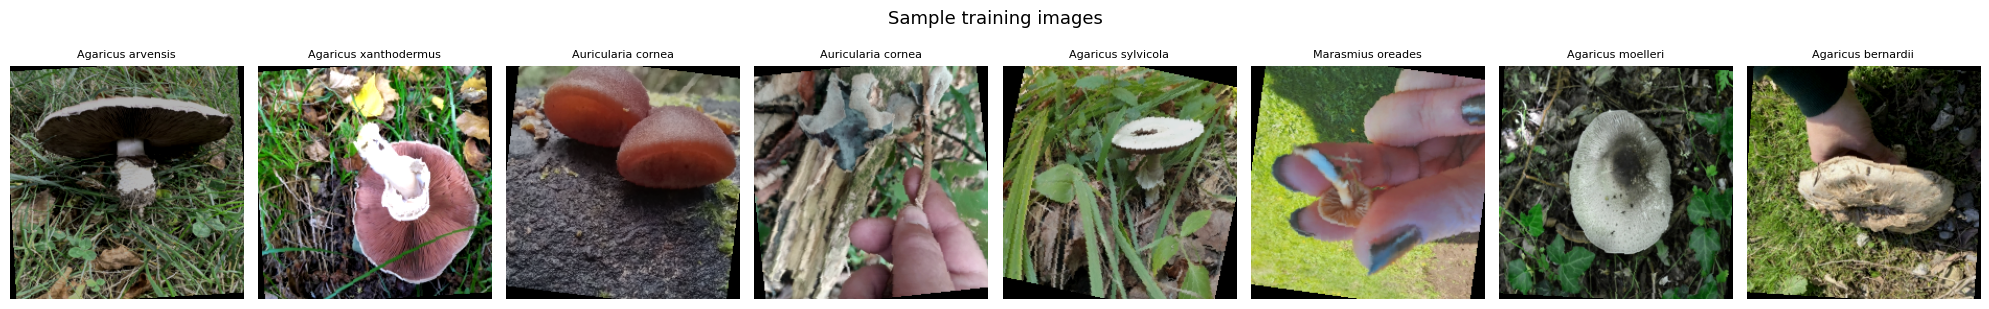

In [14]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

imgs, labels, is_non_edible = next(iter(train_loader))
n_show = min(8, BATCH_SIZE)
fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
for ax, img, lbl in zip(axes, imgs[:n_show], labels[:n_show]):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(idx2label[lbl.item()], fontsize=8)
    ax.axis("off")
plt.suptitle("Sample training images", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 7 · Build the VGG19 model

In [15]:
def build_vgg19(num_classes: int, strategy: str = "last_block") -> nn.Module:
    """
    Load pretrained VGG19 and swap the classifier head.

    Freeze policy
    -------------
    head_only  : all features frozen
    last_block : only features[28:] (conv block 5) + classifier trainable
    full       : nothing frozen
    """
    weights = models.VGG19_Weights.IMAGENET1K_V1
    model   = models.vgg19(weights=weights)

    # Freeze backbone
    for param in model.features.parameters():
        param.requires_grad = False

    if strategy == "last_block":
        # Unfreeze last convolutional block (layers 28–35 in VGG19.features)
        for layer in model.features[28:]:
            for param in layer.parameters():
                param.requires_grad = True
    elif strategy == "full":
        for param in model.features.parameters():
            param.requires_grad = True

    # Replace classifier head
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(1024, num_classes),
    )

    return model


model = build_vgg19(NUM_CLASSES, FINETUNE_STRATEGY).to(DEVICE)

# Trainable parameter count
total   = sum(p.numel() for p in model.parameters())
trained = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total:,}")
print(f"Trainable params : {trained:,}  ({100*trained/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 210MB/s]  


Total params     : 127,011,931
Trainable params : 116,426,779  (91.7%)


## 8 · Loss, optimiser & scheduler

In [16]:
# Class-weighted loss for species imbalance + sample boost for non-edible recall
class_counts = train_df["label_idx"].value_counts().sort_index().values
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(DEVICE)
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights, reduction="none")
class_is_non_edible_t = torch.tensor(class_is_non_edible, dtype=torch.int64, device=DEVICE)

# Differential learning rates: backbone gets 10× smaller lr
backbone_params    = [p for n, p in model.named_parameters()
                      if p.requires_grad and "classifier" not in n]
classifier_params  = model.classifier.parameters()

optimizer = optim.AdamW([
    {"params": backbone_params,   "lr": LEARNING_RATE / 10},
    {"params": classifier_params, "lr": LEARNING_RATE},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print("Optimizer & scheduler ready !")


Optimizer & scheduler ready !


## 9 · Training loop

In [17]:
def run_epoch(loader, model, criterion, optimizer=None, phase="train"):
    """One epoch of train or eval. Returns (loss, species_acc, non_edible_recall)."""
    is_train = phase == "train"
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    tp_non_edible, fn_non_edible = 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, labels, is_non_edible in tqdm(loader, desc=phase, leave=False):
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            is_non_edible = is_non_edible.to(DEVICE)

            logits = model(imgs)
            loss_vec = criterion(logits, labels)
            sample_weights = torch.where(
                is_non_edible == 1,
                torch.full_like(loss_vec, EDIBILITY_RECALL_BOOST),
                torch.ones_like(loss_vec),
            )
            loss = (loss_vec * sample_weights).mean()

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

            pred_non_edible = class_is_non_edible_t[preds]
            tp_non_edible += ((pred_non_edible == 1) & (is_non_edible == 1)).sum().item()
            fn_non_edible += ((pred_non_edible == 0) & (is_non_edible == 1)).sum().item()

    non_edible_recall = tp_non_edible / max(1, tp_non_edible + fn_non_edible)
    return total_loss / total, correct / total, non_edible_recall


# Main training loop
history = defaultdict(list)
best_val_non_edible_recall = -1.0
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # Optional: unfreeze full backbone after warm-up
    if FINETUNE_STRATEGY == "full" and epoch == WARMUP_EPOCHS + 1:
        for param in model.features.parameters():
            param.requires_grad = True
        print(f"  [Epoch {epoch}] Full backbone unfrozen.")

    train_loss, train_acc, train_non_ed_recall = run_epoch(train_loader, model, criterion, optimizer, "train")
    val_loss, val_acc, val_non_ed_recall = run_epoch(val_loader, model, criterion, None, "val")
    scheduler.step()

    elapsed = time.time() - t0
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["train_non_ed_recall"].append(train_non_ed_recall)
    history["val_non_ed_recall"].append(val_non_ed_recall)

    print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
          f"Train loss {train_loss:.4f} acc {train_acc:.3f} non-ed-recall {train_non_ed_recall:.3f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.3f} non-ed-recall {val_non_ed_recall:.3f} | "
          f"{elapsed:.1f}s")

    # Always save checkpoint for this epoch
    epoch_save_path = MODEL_SAVE_PATH.replace(".pt", f"_epoch{epoch}.pt")
    
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "val_acc": val_acc,
        "val_non_edible_recall": val_non_ed_recall,
        "classes": classes,
        "label2idx": label2idx,
    }, epoch_save_path)
    
    print(f"     Checkpoint saved: {epoch_save_path}")


    is_better = (
        (val_non_ed_recall > best_val_non_edible_recall) or
        (np.isclose(val_non_ed_recall, best_val_non_edible_recall) and val_acc > best_val_acc)
    )

    if is_better:
        best_val_non_edible_recall = val_non_ed_recall
        best_val_acc = val_acc
        torch.save({
            "epoch":      epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc":    val_acc,
            "val_non_edible_recall": val_non_ed_recall,
            "classes":    classes,
            "label2idx":  label2idx,
        }, MODEL_SAVE_PATH)
        print(f"     New best model saved (val_non_edible_recall={val_non_ed_recall:.4f}, val_acc={val_acc:.4f})")

print(f"\nTraining complete. Best val non-edible recall: {best_val_non_edible_recall:.4f} (val acc={best_val_acc:.4f})")

train:   0%|          | 0/848 [00:00<?, ?it/s]

val:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch   1/20 | Train loss 0.0158 acc 0.408 non-ed-recall 0.792 | Val loss 0.0127 acc 0.640 non-ed-recall 0.804 | 612.7s
     Checkpoint saved: best_vgg19_mushroom_epoch1.pth
     New best model saved (val_non_edible_recall=0.8041, val_acc=0.6400)


train:   0%|          | 0/848 [00:00<?, ?it/s]

val:   0%|          | 0/170 [00:00<?, ?it/s]

...

Epoch   6/20 | Train loss 0.0072 acc 0.626 non-ed-recall 0.791 | Val loss 0.0109 acc 0.724 non-ed-recall 0.874 | 617.6s
     Checkpoint saved: best_vgg19_mushroom_epoch6.pth
     New best model saved (val_non_edible_recall=0.8738, val_acc=0.7237)


train:   0%|          | 0/848 [00:00<?, ?it/s]

val:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch   7/20 | Train loss 0.0066 acc 0.652 non-ed-recall 0.804 | Val loss 0.0104 acc 0.654 non-ed-recall 0.801 | 611.5s


RuntimeError: [enforce fail at inline_container.cc:668] . unexpected pos 80113472 vs 80113360

## 10 · Learning curves

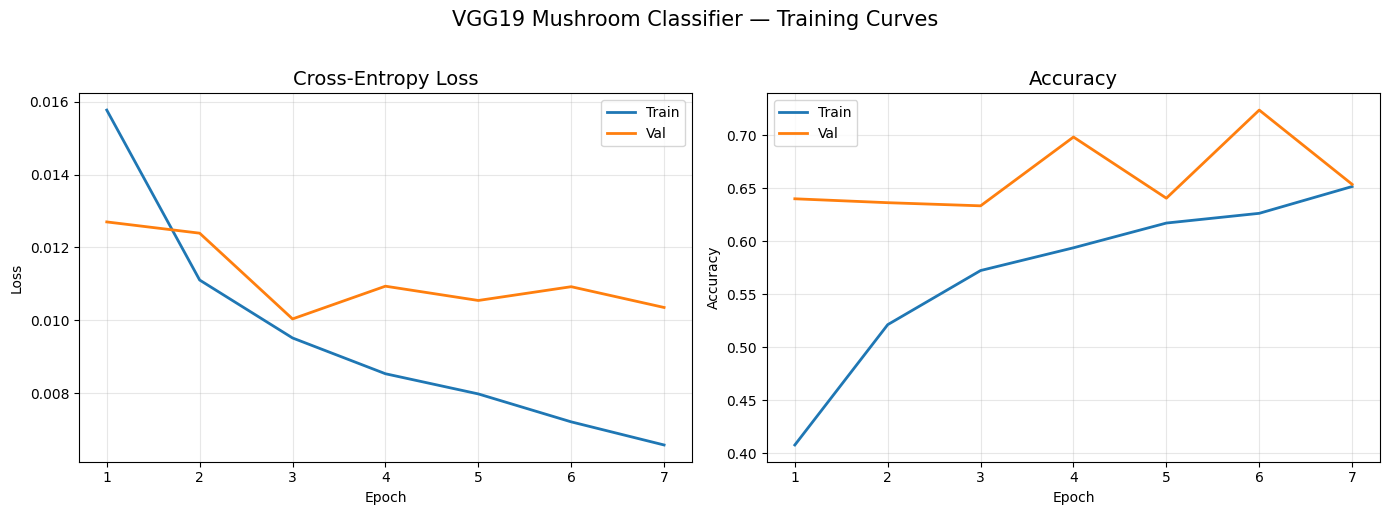

In [18]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, history["train_loss"], label="Train", linewidth=2)
axes[0].plot(epochs, history["val_loss"],   label="Val",   linewidth=2)
axes[0].set_title("Cross-Entropy Loss", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, history["train_acc"], label="Train", linewidth=2)
axes[1].plot(epochs, history["val_acc"],   label="Val",   linewidth=2)
axes[1].set_title("Accuracy", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("VGG19 Mushroom Classifier — Training Curves", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 11 · Evaluate on the test set

In [19]:
# Load best checkpoint
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

all_preds, all_labels, all_probs, all_non_ed_true = [], [], [], []

with torch.no_grad():
    for imgs, labels, is_non_edible in tqdm(test_loader, desc="Test"):
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_non_ed_true.extend(is_non_edible.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_non_ed_true = np.array(all_non_ed_true)

test_acc = (all_preds == all_labels).mean()
print(f"\nTest accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("\nClassification report (species):")
print(classification_report(all_labels, all_preds, target_names=classes))

# Safety metric from species probabilities: P(non-edible) = sum P(species in non-edible set)
non_edible_mask = class_is_non_edible.astype(bool)
non_edible_score = all_probs[:, non_edible_mask].sum(axis=1)

pred_non_ed_05 = (non_edible_score >= 0.5).astype(np.int64)
rec_05 = recall_score(all_non_ed_true, pred_non_ed_05, zero_division=0)
pre_05 = precision_score(all_non_ed_true, pred_non_ed_05, zero_division=0)
print(f"\nNon-edible detection @0.50 -> precision={pre_05:.4f}, recall={rec_05:.4f}")

thresholds = np.linspace(0.05, 0.95, 37)
rows = []
for t in thresholds:
    pred_non_ed = (non_edible_score >= t).astype(np.int64)
    pre = precision_score(all_non_ed_true, pred_non_ed, zero_division=0)
    rec = recall_score(all_non_ed_true, pred_non_ed, zero_division=0)
    rows.append((t, pre, rec))

valid = [r for r in rows if r[1] >= 0.60]
best = max(valid, key=lambda x: x[2]) if valid else max(rows, key=lambda x: x[2])
print(f"Best non-edible threshold: {best[0]:.2f} (precision={best[1]:.4f}, recall={best[2]:.4f})")

Test:   0%|          | 0/113 [00:00<?, ?it/s]


Test accuracy: 0.7209 (72.09%)

Classification report (species):
                           precision    recall  f1-score   support

                 Agaricus       0.00      0.00      0.00        20
        Agaricus arvensis       0.43      0.04      0.07        76
        Agaricus augustus       0.77      0.74      0.76       376
       Agaricus bernardii       0.26      0.41      0.32        44
        Agaricus bisporus       0.04      0.14      0.06        14
       Agaricus bitorquis       0.62      0.47      0.54       133
         Agaricus bohusii       0.28      0.83      0.42        12
    Agaricus bresadolanus       0.25      0.17      0.20         6
      Agaricus campestris       0.60      0.36      0.45       320
    Agaricus crocodilinus       0.04      0.36      0.07        14
        Agaricus moelleri       0.29      0.60      0.39        47
      Agaricus sylvaticus       0.28      0.45      0.34        38
       Agaricus sylvicola       0.39      0.26      0.32      

### Confusion matrix

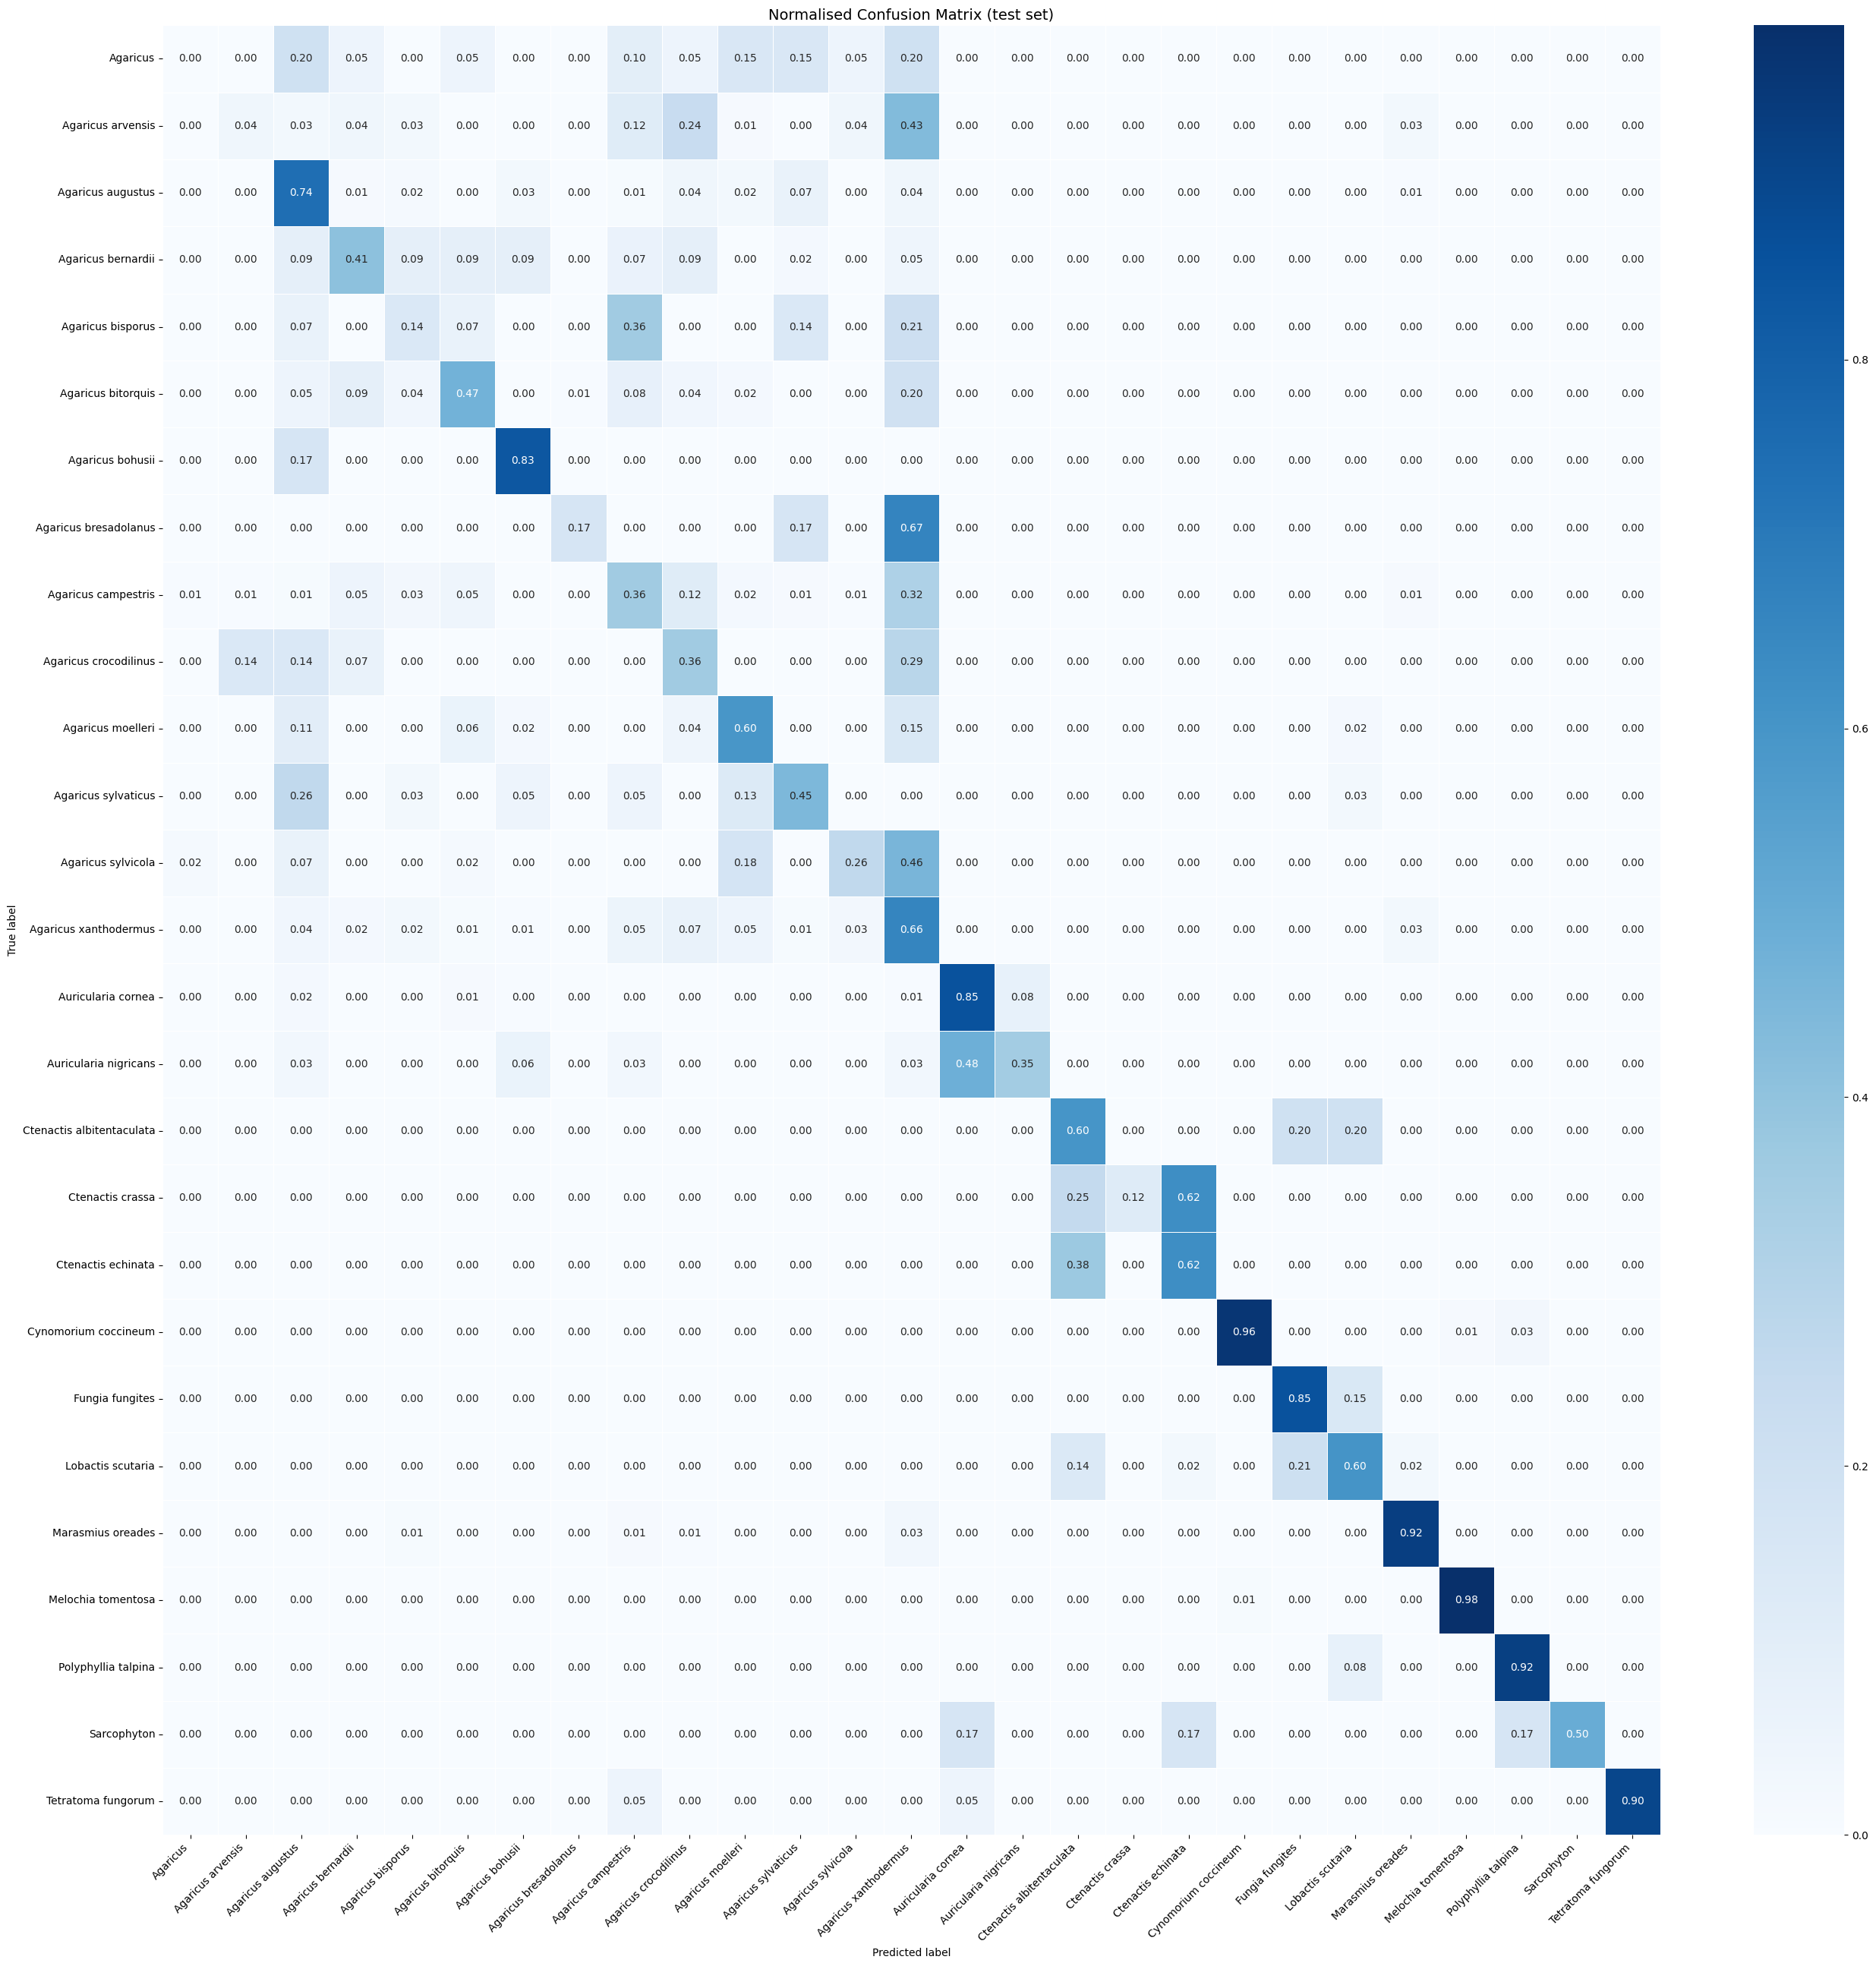

In [20]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalise rows

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES), max(7, NUM_CLASSES - 1)))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax)
ax.set_title("Normalised Confusion Matrix (test set)", fontsize=14)
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 12 · Upload best model to S3

In [24]:

epoch_s3_key = f"vgg19_mushroom_epoch{epoch}.pth"
s3.upload_file(epoch_save_path, S3_BUCKET, epoch_s3_key)

print(f"     Uploaded checkpoint → s3://{S3_BUCKET}/{epoch_s3_key}")

     Uploaded checkpoint → s3://fungiapp/vgg19_mushroom_epoch7.pth


## 13 · Inference helper

In [ ]:
def predict_from_s3(s3_key: str, top_k: int = 3):
    """
    Predict the mushroom species from a single S3 image.

    Parameters
    ----------
    s3_key : str
        Full S3 key, e.g. 'images/amanita_001.jpg'
    top_k  : int
        Number of top predictions to display
    """
    obj = s3.get_object(Bucket=S3_BUCKET, Key=s3_key)
    img = Image.open(io.BytesIO(obj["Body"].read())).convert("RGB")

    tensor = val_transform(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    top_idx  = probs.argsort()[::-1][:top_k]
    top_probs = probs[top_idx]
    top_names = [idx2label[i] for i in top_idx]

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(10, 4),
                             gridspec_kw={"width_ratios": [1, 1.5]})
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(s3_key.split("/")[-1], fontsize=10)

    colors = ["#2196F3" if i == 0 else "#90CAF9" for i in range(top_k)]
    axes[1].barh(top_names[::-1], top_probs[::-1], color=colors[::-1], edgecolor="white")
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probability")
    axes[1].set_title("Top-K predictions", fontsize=12)
    for i, (name, prob) in enumerate(zip(top_names[::-1], top_probs[::-1])):
        axes[1].text(prob + 0.01, i, f"{prob:.2%}", va="center", fontsize=10)
    plt.tight_layout()
    plt.show()

    return dict(zip(top_names, top_probs))


In [ ]:
---
## Summary

| Step | Detail |
|------|--------|
| Backbone | VGG19 pretrained on ImageNet |
| Fine-tune strategy | Last conv block + custom head |
| Classifier head | FC(25088→4096) → FC(4096→1024) → FC(1024→*N*) |
| Loss | CrossEntropy with class weights |
| Optimiser | AdamW with differential LR |
| Scheduler | CosineAnnealing |
| Augmentation | RandomCrop, Flip, ColorJitter, Rotation |
| Best model | Saved locally & uploaded to S3 |